In [14]:
import pandas as pd
df=pd.read_csv('online_shoppers_intention.csv')
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,...,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,...,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,...,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,...,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,...,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,...,3,1,4,Returning_Visitor,True,False


Διαστάσεις Dataset (Γραμμές, Στήλες): (12330, 18)


Πληροφορίες Στηλών (Data Types):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int6

,Administrative_Duration,Informational_Duration,ProductRelated_Duration,BounceRates,ExitRates,PageValues
0,-0.460019,-0.246257,-0.628793,3.969402,3.434394,-0.318962
1,-0.460019,-0.246257,-0.595451,-0.450137,1.268054,-0.318962
2,-0.460019,-0.246257,-0.628793,3.969402,3.434394,-0.318962
3,-0.460019,-0.246257,-0.627404,0.654748,2.134590,-0.318962
4,-0.460019,-0.246257,-0.301889,-0.008183,0.184884,-0.318962


Διακριτοποίηση των δεδομένων:


,ProductRelated,ProductRelated_Category,ProductRelated_Duration
0,1,Low,-0.628793
1,2,Low,-0.595451
2,1,Low,-0.628793
3,2,Low,-0.627404
4,10,Low,-0.301889


Νέο μέγεθος του dataset: (12205, 30)



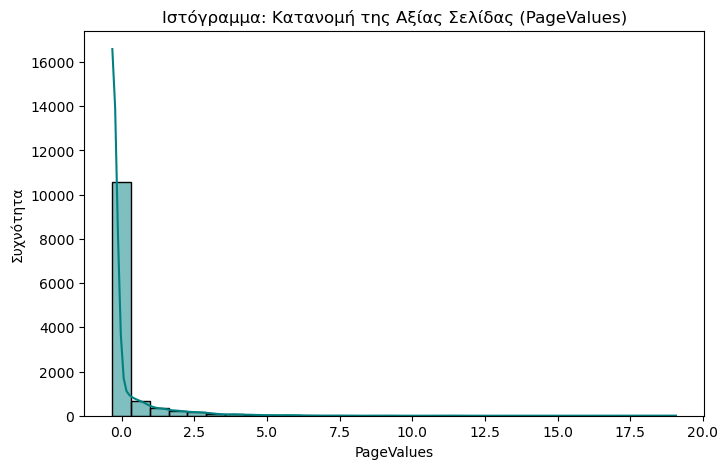

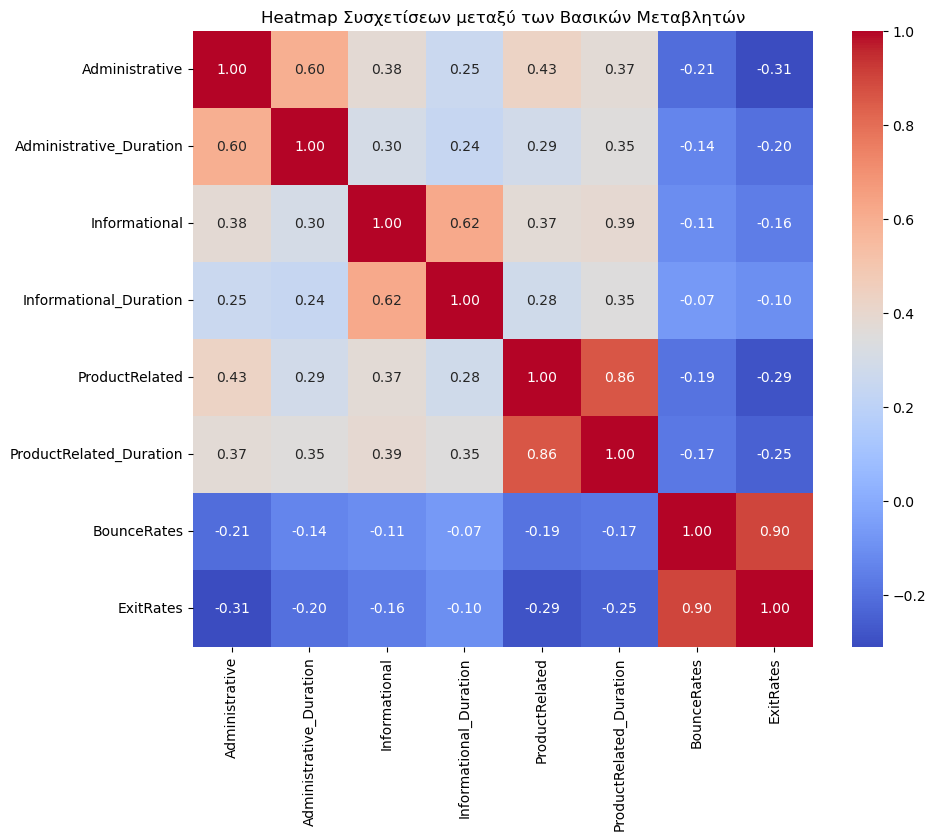

Τελικές διαστάσεις του Dataset (Γραμμές, Στήλες): (12205, 29)


In [15]:
print ("Διαστάσεις Dataset (Γραμμές, Στήλες):",df.shape)
print("\n" + "="*40 + "\n")
print("Πληροφορίες Στηλών (Data Types):")
df.info()
print("\n" + "="*40 + "\n")
print("Πλήθος ελλιπών τιμών (Missing Values) ανά στήλη:")
print(df.isnull().sum())
print("\n" + "="*40 + "\n")
df=df.drop_duplicates()
print(f"\nΜέγεθος αρχείου μετά την αφαίρεση διπλότυπων: {df.shape}")
print("\n" + "="*40 + "\n")
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols = ['Administrative_Duration', 'Informational_Duration','ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues']
df[num_cols] = scaler.fit_transform(df[num_cols])
print("Πρώτες γραμμές μετά την κανονικοποίση:")
display(df[num_cols].head())
df['ProductRelated_Category'] = pd.qcut(df['ProductRelated'], q=3, labels=['Low', 'Medium', 'High'])
print("Διακριτοποίηση των δεδομένων:")
display(df[['ProductRelated', 'ProductRelated_Category', 'ProductRelated_Duration']].head())
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)
df = pd.get_dummies(df, columns=['Month', 'VisitorType'], dtype=int)
print(f"Νέο μέγεθος του dataset: {df.shape}\n")
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.histplot(df['PageValues'], bins=30, kde=True, color='teal')
plt.title('Ιστόγραμμα: Κατανομή της Αξίας Σελίδας (PageValues)')
plt.ylabel('Συχνότητα')
plt.show()
cols_to_check = ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 
                 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates']
plt.figure(figsize=(10, 8))
sns.heatmap(df[cols_to_check].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Συσχετίσεων μεταξύ των Βασικών Μεταβλητών')
plt.show()
df = df.drop(columns=['BounceRates'])
print(f"Τελικές διαστάσεις του Dataset (Γραμμές, Στήλες): {df.shape}")

ΑΠΟΤΕΛΕΣΜΑΤΑ K-MEANS
Χρόνος: 0.008 δευτερόλεπτα
Βαθμολογία Σιλουέτας (Ποιότητα ομάδων): 0.328

ΑΠΟΤΕΛΕΣΜΑΤΑ DBSCAN
Χρόνος: 3.088 δευτερόλεπτα
Ομάδες που είναι μόνες του: 2
Χρήστες με περίεργη συμπεριφορά: 530


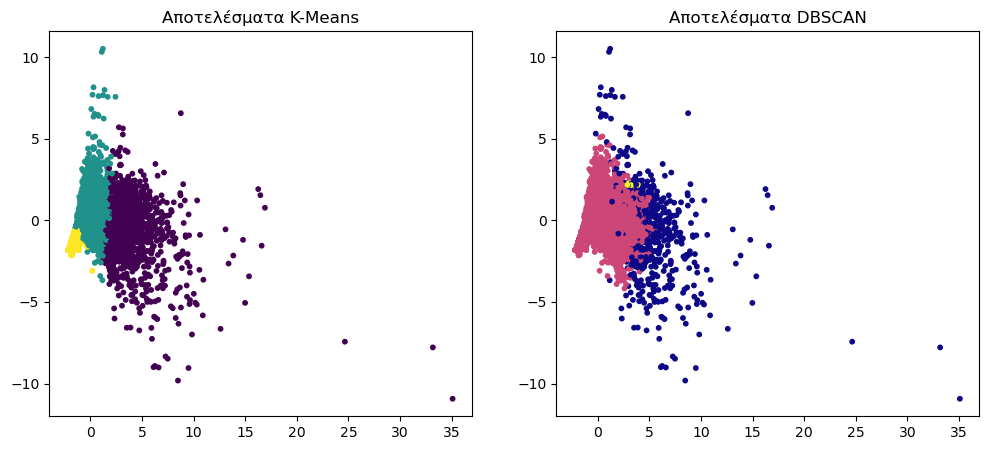

In [16]:
import time
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn import metrics
from sklearn.decomposition import PCA
features = [
    'Administrative', 'Administrative_Duration', 
    'Informational', 'Informational_Duration', 
    'ProductRelated', 'ProductRelated_Duration', 
    'ExitRates', 'PageValues'
]
X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("ΑΠΟΤΕΛΕΣΜΑΤΑ K-MEANS")
start_time = time.time()
kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)
time_kmeans = time.time() - start_time
print(f"Χρόνος: {time_kmeans:.3f} δευτερόλεπτα")
print(f"Βαθμολογία Σιλουέτας (Ποιότητα ομάδων): {metrics.silhouette_score(X_scaled, labels_kmeans):.3f}")
print("\nΑΠΟΤΕΛΕΣΜΑΤΑ DBSCAN")
start_time = time.time()
dbscan = DBSCAN(eps=1.5, min_samples=10)
labels_dbscan = dbscan.fit_predict(X_scaled)
time_dbscan = time.time() - start_time
n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = list(labels_dbscan).count(-1)
print(f"Χρόνος: {time_dbscan:.3f} δευτερόλεπτα")
print(f"Ομάδες που είναι μόνες του: {n_clusters}")
print(f"Χρήστες με περίεργη συμπεριφορά: {n_noise}")
pca = PCA(n_components=2)
X_2D = pca.fit_transform(X_scaled)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
# Γράφημα για K-Means
ax1.scatter(X_2D[:, 0], X_2D[:, 1], c=labels_kmeans, cmap='viridis', s=10)
ax1.set_title('Αποτελέσματα K-Means')
# Γράφημα για DBSCAN
ax2.scatter(X_2D[:, 0], X_2D[:, 1], c=labels_dbscan, cmap='plasma', s=10)
ax2.set_title('Αποτελέσματα DBSCAN')
plt.show()

ΑΠΟΤΕΛΕΣΜΑΤΑ: Gaussian Naive Bayes
Confusion Matrix:
 [[1605  474]
 [ 101  261]]
Accuracy = 0.7644408029496108
Precision = 0.6479496136086322
Recall = 0.7465001235719468
F-score = 0.6619638765023861

ΑΠΟΤΕΛΕΣΜΑΤΑ: Random Forest Classifier
Confusion Matrix:
 [[2010   69]
 [ 164  198]]
Accuracy = 0.9045473166734944
Precision = 0.833068025593583
Recall = 0.7568861463889088
F-score = 0.7873929447351669


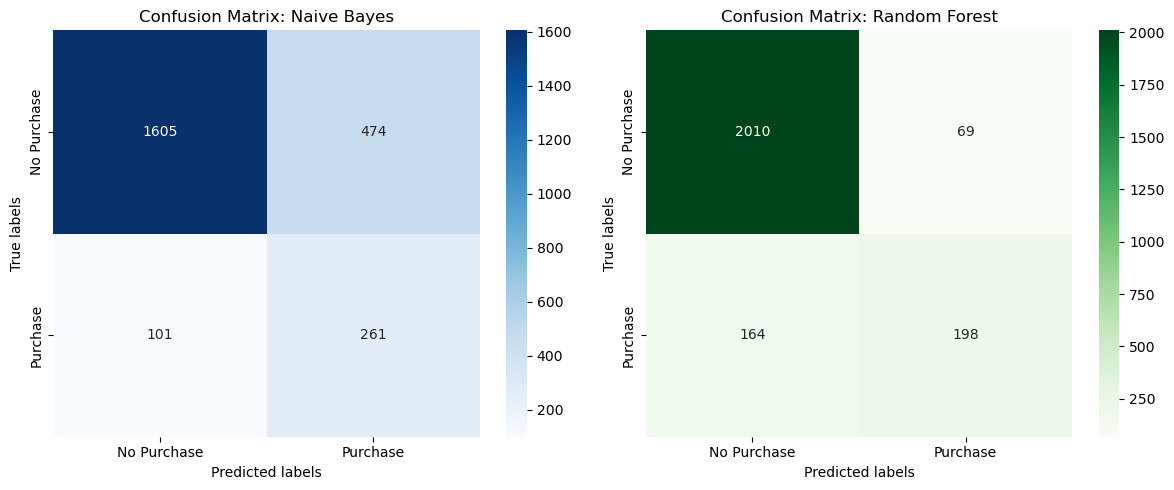

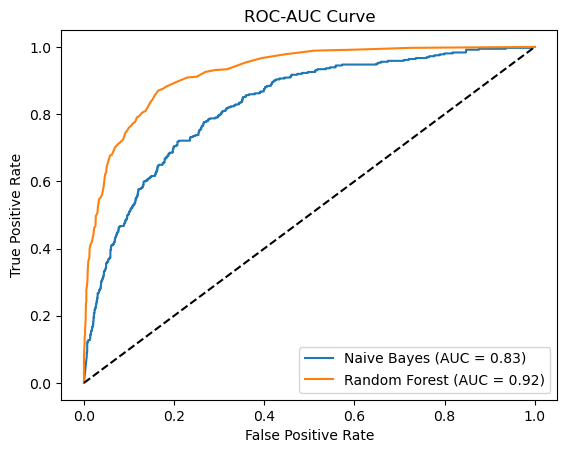

In [9]:
import numpy as np
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_fscore_support
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', 12)
df = pd.get_dummies(df, drop_first=True)
target_df = df['Revenue']
y = pd.DataFrame(target_df).to_numpy().ravel()
df = df.drop(['Revenue'], axis=1)
X = pd.DataFrame(df).to_numpy()
X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("ΑΠΟΤΕΛΕΣΜΑΤΑ: Gaussian Naive Bayes")
clf_nb = GaussianNB()
clf_nb.fit(X_train, y_train)
y_pred_nb = clf_nb.predict(X_test)
cm_nb = confusion_matrix(y_test, y_pred_nb)
print("Confusion Matrix:\n", cm_nb)
print('Accuracy = ' + str(clf_nb.score(X_test, y_test)))
clf_metrics_nb = precision_recall_fscore_support(y_test, y_pred_nb, average='macro')
clf_metrics_labels = ['Precision', 'Recall', 'F-score', 'Support']
for i in range(0, 3): 
    print(clf_metrics_labels[i] + ' = ' + str(clf_metrics_nb[i]))
print("\nΑΠΟΤΕΛΕΣΜΑΤΑ: Random Forest Classifier")
clf_rf = RandomForestClassifier(random_state=42)
clf_rf.fit(X_train, y_train)
y_pred_rf = clf_rf.predict(X_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:\n", cm_rf)
print('Accuracy = ' + str(clf_rf.score(X_test, y_test)))
clf_metrics_rf = precision_recall_fscore_support(y_test, y_pred_rf, average='macro')
for i in range(0, 3):
    print(clf_metrics_labels[i] + ' = ' + str(clf_metrics_rf[i]))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_nb, annot=True, fmt='g', ax=ax1, cmap='Blues')
ax1.set_xlabel('Predicted labels')
ax1.set_ylabel('True labels')
ax1.set_title('Confusion Matrix: Naive Bayes')
ax1.xaxis.set_ticklabels(['No Purchase', 'Purchase'])
ax1.yaxis.set_ticklabels(['No Purchase', 'Purchase'])
sns.heatmap(cm_rf, annot=True, fmt='g', ax=ax2, cmap='Greens')
ax2.set_xlabel('Predicted labels')
ax2.set_ylabel('True labels')
ax2.set_title('Confusion Matrix: Random Forest')
ax2.xaxis.set_ticklabels(['No Purchase', 'Purchase'])
ax2.yaxis.set_ticklabels(['No Purchase', 'Purchase'])
plt.tight_layout()
plt.show()
from sklearn.metrics import roc_curve, auc
# Υπολογισμός πιθανοτήτων
y_pred_prob_nb = clf_nb.predict_proba(X_test)[:, 1]
y_pred_prob_rf = clf_rf.predict_proba(X_test)[:, 1]
# Υπολογισμός FPR, TPR και AUC για τα δύο μοντέλα
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_pred_prob_nb)
roc_auc_nb = auc(fpr_nb, tpr_nb)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
ax = plt.subplot()
ax.plot(fpr_nb, tpr_nb, label='Naive Bayes (AUC = %0.2f)' % roc_auc_nb)
ax.plot(fpr_rf, tpr_rf, label='Random Forest (AUC = %0.2f)' % roc_auc_rf)
ax.plot([0, 1], [0, 1], 'k--') # Γραμμή τυχαίας πρόβλεψης
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC-AUC Curve')
ax.legend(loc="lower right")
plt.show()

In [10]:
%pip install pyspark

Note: you may need to restart the kernel to use updated packages.


In [11]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("Step4_BigData").getOrCreate()
df = spark.read.format('csv').options(header='true', inferSchema='true').load("online_shoppers_intention.csv")
df = df.dropDuplicates().dropna()
from pyspark.sql.functions import col, when
df = df.withColumn("label", when(col("Revenue") == True, 1.0).otherwise(0.0))
df = df.withColumn("Weekend_num", when(col("Weekend") == True, 1.0).otherwise(0.0))
from pyspark.ml.feature import VectorAssembler
feature_cols = ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 
                'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 
                'SpecialDay', 'Weekend_num']
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
df = assembler.transform(df)
train_data, test_data = df.randomSplit([0.8, 0.2], seed=42)
from pyspark.ml.classification import DecisionTreeClassifier, LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
evaluator_prec = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
evaluator_rec = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
evaluator_auc = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
dt = DecisionTreeClassifier(featuresCol="features", labelCol="label", maxDepth=10)
model_dt = dt.fit(train_data)
test_predictions_dt = model_dt.transform(test_data)

print("Αποτελέσματα Decision Tree")
print(f"Testing accuracy:  {evaluator_acc.evaluate(test_predictions_dt):.4f}")
print(f"Testing Precision: {evaluator_prec.evaluate(test_predictions_dt):.4f}")
print(f"Testing Recall:    {evaluator_rec.evaluate(test_predictions_dt):.4f}")
print(f"Testing F1-score:  {evaluator_f1.evaluate(test_predictions_dt):.4f}")
print(f"Testing AUC:       {evaluator_auc.evaluate(test_predictions_dt):.4f}")
# Σχόλιο: Το AUC του Decision Tree εμφανίζεται παράδοξα χαμηλό (<0.5) παρά την καλή ακρίβεια/F1.
# Αυτό συμβαίνει επειδή η στήλη 'rawPrediction' του Decision Tree περιέχει counts ανά φύλλο
# (όχι ομαλές πιθανότητες), και σε συνδυασμό με την ανισορροπία των κλάσεων (~15.5% Purchase)
# το ranking που χρησιμοποιεί ο BinaryClassificationEvaluator για τη ROC καμπύλη παραμορφώνεται.
# Το Logistic Regression παράγει πιο αξιόπιστες πιθανότητες, γι' αυτό έχει πολύ καλύτερο AUC.
lr = LogisticRegression(featuresCol="features", labelCol="label", regParam=0.1)
model_lr = lr.fit(train_data)
test_predictions_lr = model_lr.transform(test_data)

print("Αποτελέσματα Logistic Regression")
print(f"Testing accuracy:  {evaluator_acc.evaluate(test_predictions_lr):.4f}")
print(f"Testing Precision: {evaluator_prec.evaluate(test_predictions_lr):.4f}")
print(f"Testing Recall:    {evaluator_rec.evaluate(test_predictions_lr):.4f}")
print(f"Testing F1-score:  {evaluator_f1.evaluate(test_predictions_lr):.4f}")
print(f"Testing AUC:       {evaluator_auc.evaluate(test_predictions_lr):.4f}")
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

evaluator_silhouette = ClusteringEvaluator(featuresCol="features", metricName="silhouette")

print("K-Means Clustering Silhouette Scores")
for k in range(2, 6):
    kmeans = KMeans(featuresCol="features", k=k, seed=42)
    model_kmeans = kmeans.fit(df)
    predictions_kmeans = model_kmeans.transform(df)
    
    sil_score = evaluator_silhouette.evaluate(predictions_kmeans)
    print(f"Για k={k}, Silhouette Score: {sil_score:.4f}")

spark.stop()

Αποτελέσματα Decision Tree
Testing accuracy:  0.8757
Testing Precision: 0.8722
Testing Recall:    0.8757
Testing F1-score:  0.8738
Testing AUC:       0.4653
Αποτελέσματα Logistic Regression
Testing accuracy:  0.8556
Testing Precision: 0.8363
Testing Recall:    0.8556
Testing F1-score:  0.8186
Testing AUC:       0.8728
K-Means Clustering Silhouette Scores
Για k=2, Silhouette Score: 0.8939
Για k=3, Silhouette Score: 0.8360
Για k=4, Silhouette Score: 0.8180
Για k=5, Silhouette Score: 0.7766


ΠΑΡΑΓΟΝΤΕΣ ΓΥΡΟ ΑΠΟ ΤΗΝ ΠΙΘΑΝΟΤΗΤΑ ΑΓΟΡΑΣ
                                           antecedents consequents  support  confidence   lift
88                     (PageValue_High, ExitRates_Low)  (Purchase)    0.076       0.643  4.157
304           (Weekday, PageValue_High, ExitRates_Low)  (Purchase)    0.055       0.633  4.088
296  (ExitRates_Low, Returning_Visitor, PageValue_H...  (Purchase)    0.054       0.583  3.767
28                                    (PageValue_High)  (Purchase)    0.125       0.563  3.641
184                          (Weekday, PageValue_High)  (Purchase)    0.092       0.557  3.599


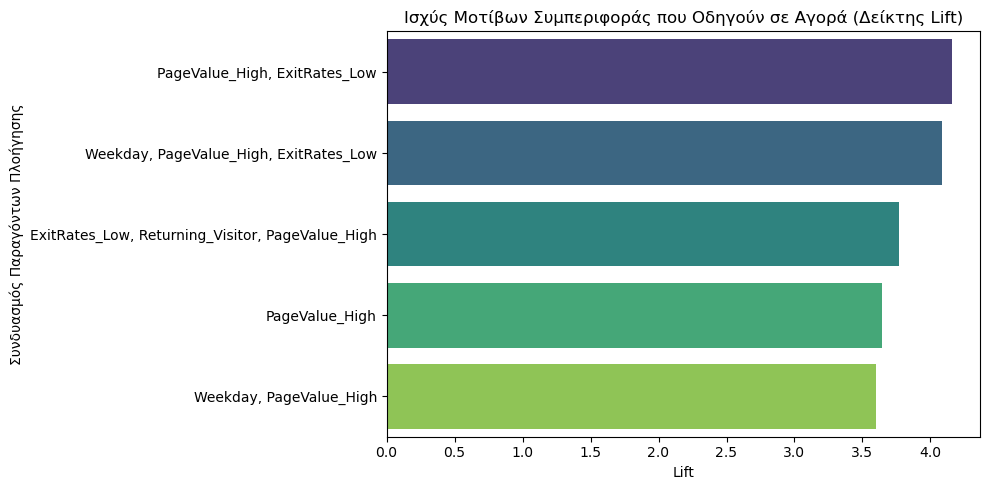

In [12]:
import pandas as pd
df=pd.read_csv('online_shoppers_intention.csv')
df.head()
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', 12)
df_rules = df[['PageValues', 'ExitRates', 'VisitorType', 'Weekend', 'Revenue']].copy()
df_rules['PageValues'] = pd.cut(df_rules['PageValues'], bins=[-1, 0.001, 100000], labels=['PageValue_Zero', 'PageValue_High']).astype(str)
df_rules['ExitRates'] = pd.qcut(df_rules['ExitRates'], q=3, labels=['ExitRates_Low', 'ExitRates_Medium', 'ExitRates_High'], duplicates='drop').astype(str)
df_rules['Weekend'] = df_rules['Weekend'].map({False: 'Weekday', True: 'Weekend'})
df_rules['Revenue'] = df_rules['Revenue'].map({False: 'No_Purchase', True: 'Purchase'})
X = df_rules.values.tolist()
te = TransactionEncoder()
te_ary = te.fit(X).transform(X)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)
frequent_itemsets = apriori(df_encoded, min_support=0.04, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.4)
purchase_rules = rules[rules['consequents'] == frozenset({'Purchase'})].copy()
purchase_rules = purchase_rules.sort_values(by='lift', ascending=False)
print("ΠΑΡΑΓΟΝΤΕΣ ΓΥΡΟ ΑΠΟ ΤΗΝ ΠΙΘΑΝΟΤΗΤΑ ΑΓΟΡΑΣ")
print(purchase_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5).round(3))
import matplotlib.pyplot as plt
import seaborn as sns
purchase_rules['rule_name'] = purchase_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
plt.figure(figsize=(10, 5))
sns.barplot(x='lift', y='rule_name', data=purchase_rules.head(5), hue='rule_name', palette='viridis', legend=False)
plt.title('Ισχύς Μοτίβων Συμπεριφοράς που Οδηγούν σε Αγορά (Δείκτης Lift)')
plt.xlabel('Lift')
plt.ylabel('Συνδυασμός Παραγόντων Πλοήγησης')
plt.tight_layout()
plt.show()